In [183]:
library(dplyr)
library(lubridate)
library(tseries)
library(forecast)
library(lmtest)
library(tsoutliers)



In [184]:
cs <- read.csv("counter_strike.csv", sep = ';')

cs_semanal <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2025-12-31")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = mean(Players, na.rm = TRUE))

cat("Dimensões:", nrow(cs_semanal), "semanas\n")
head(cs_semanal)


Dimensões: 522 semanas


semana,jogadores
<date>,<dbl>
2016-01-04,628781.0
2016-01-11,597923.1
2016-01-18,615375.0
2016-01-25,613932.7
2016-02-01,610113.6
2016-02-08,620624.4


In [185]:
serie <- ts(cs_semanal$jogadores,
            start     = c(2016, 1),
            frequency = 52)

cat("Início:", start(serie), "| Fim:", end(serie),
    "| Observações:", length(serie), "\n")


Início: 2016 1 | Fim: 2026 2 | Observações: 522 


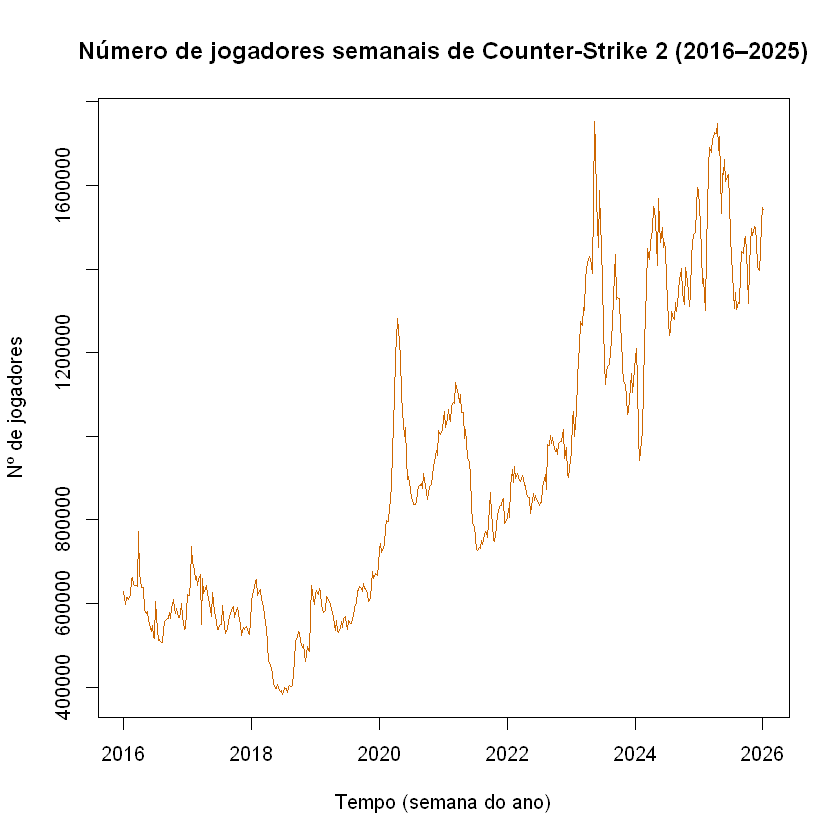

In [186]:
plot(serie,
     main = "Número de jogadores semanais de Counter-Strike 2 (2016–2025)",
     xlab = "Tempo (semana do ano)",
     ylab = "Nº de jogadores",
     col  = "darkorange3")


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 382055  599685  849719  916332 1207915 1753420 

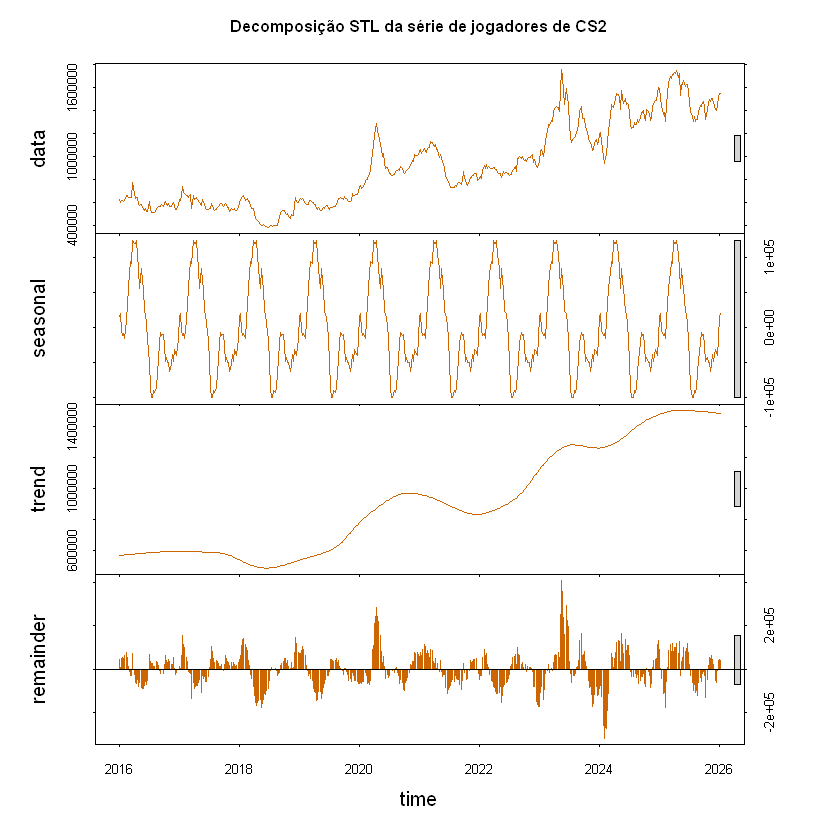

In [187]:
summary(serie)
decomp <- stl(serie, s.window = "periodic")
plot(decomp,
     main = "Decomposição STL da série de jogadores de CS2",
     col  = "darkorange3")


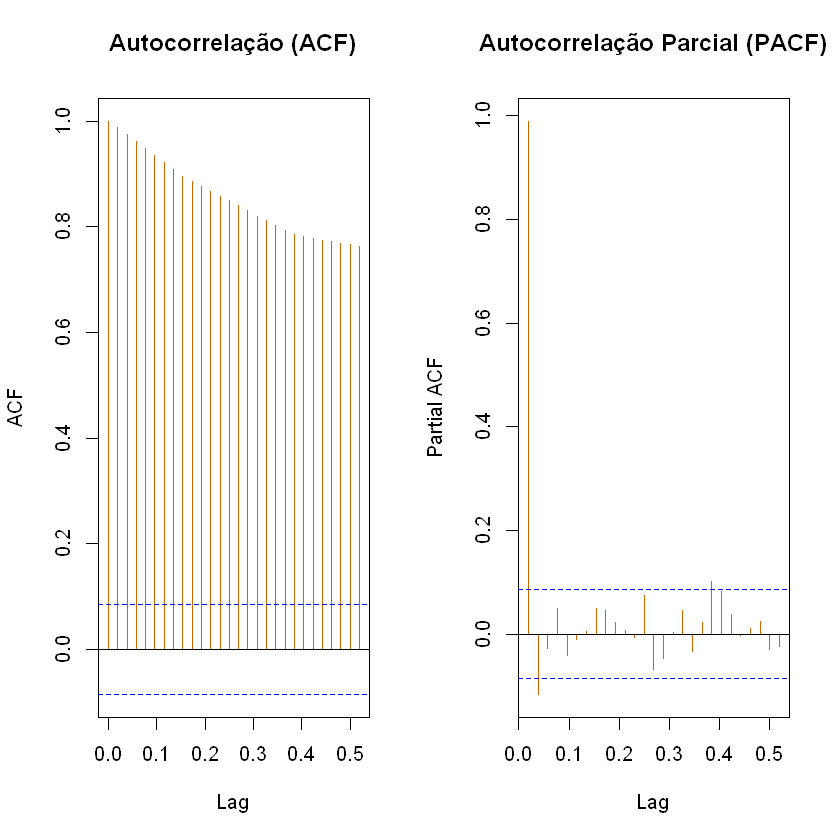

In [188]:
par(mfrow = c(1, 2))
acf (serie, main = "Autocorrelação (ACF)",         col = "darkorange3")
pacf(serie, main = "Autocorrelação Parcial (PACF)", col = "darkorange3")
par(mfrow = c(1, 1))


In [189]:
adf.test(serie)   # H0: não-estacionária
kpss.test(serie)  # H0: estacionária


	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -3.5364, Lag order = 8, p-value = 0.03881
alternative hypothesis: stationary


Warning message in kpss.test(serie):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 6.286, Truncation lag parameter = 6, p-value = 0.01


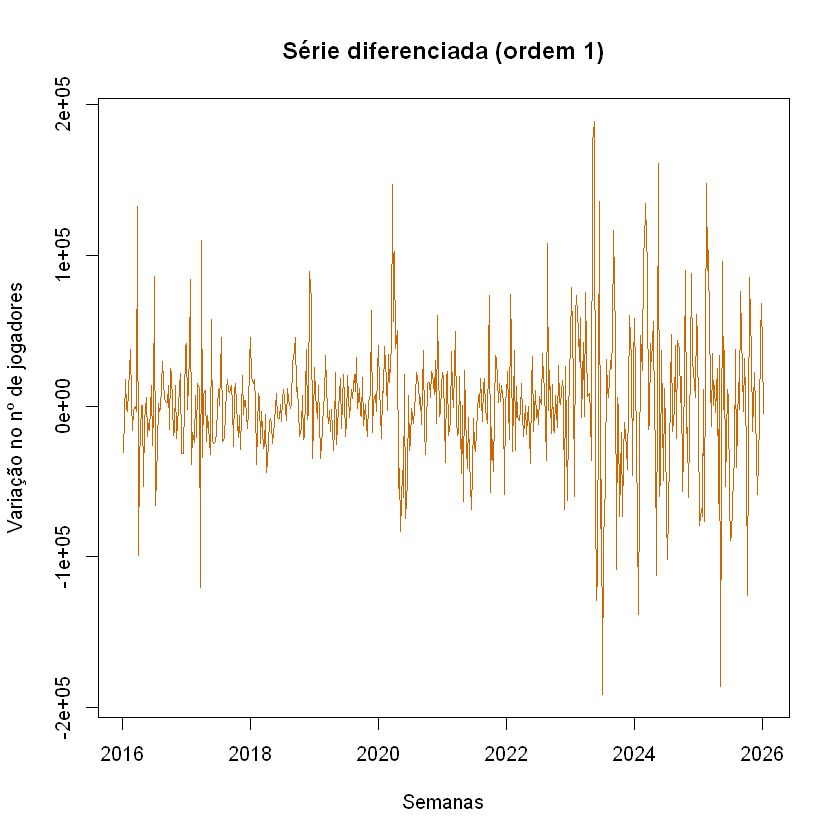

In [190]:
serie_diff <- diff(serie)

plot(serie_diff,
     main = "Série diferenciada (ordem 1)",
     xlab = "Semanas",
     ylab = "Variação no nº de jogadores",
     col  = "darkorange3")


In [191]:
adf.test(serie_diff)
kpss.test(serie_diff)

Warning message in adf.test(serie_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  serie_diff
Dickey-Fuller = -8.6564, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


Warning message in kpss.test(serie_diff):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = 0.043643, Truncation lag parameter = 6, p-value = 0.1


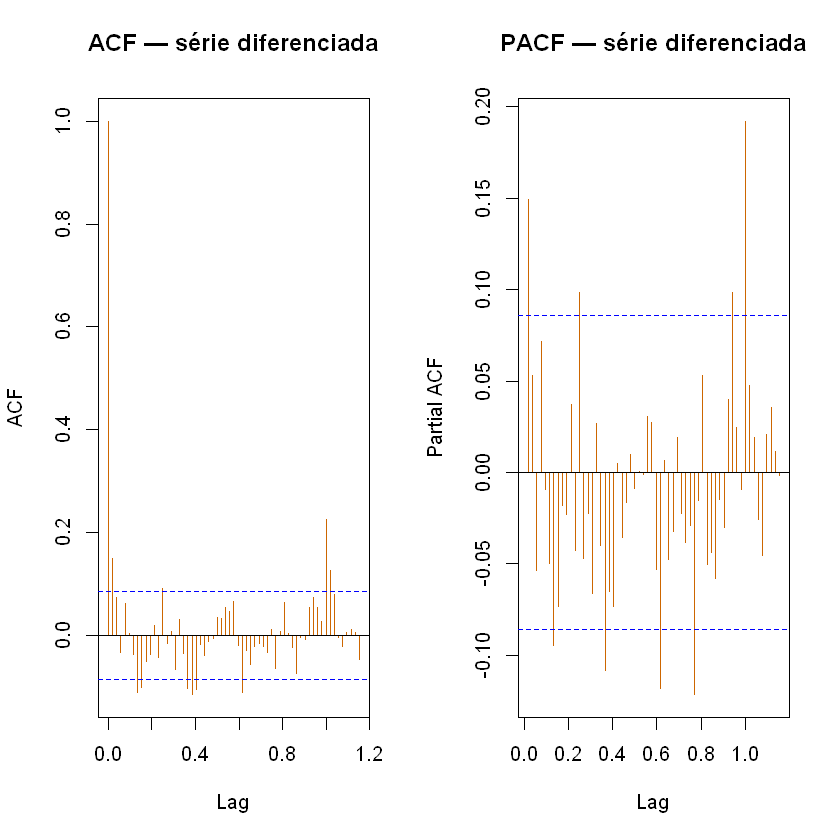

In [192]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))


In [193]:
library(tsoutliers)
#outliers3 <- tso(serie)

outliers3 <- data.frame(  # fixando outliers sem ter que rodar de novo o pacote tsoutliers
  type = c("LS","TC","LS"),
  ind  = c(220,384,391),
  stringsAsFactors = FALSE
)

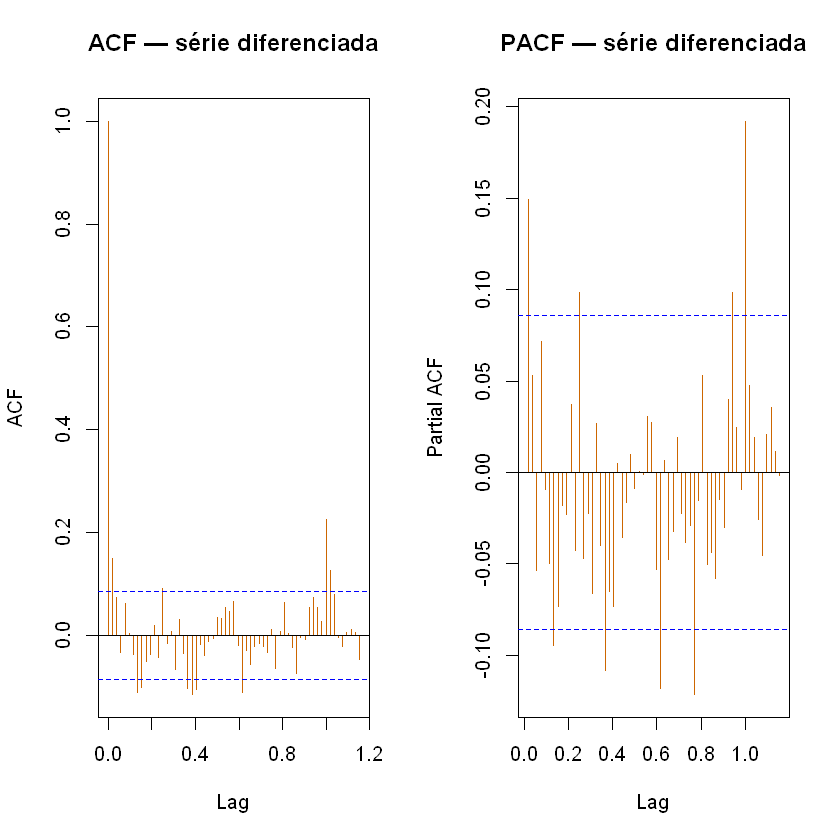

In [194]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))


In [195]:
# extrai a matriz de dummies dos outliers detectados
dummies <- outliers.effects(outliers3, n = length(serie))
# ajusta o ARIMA já considerando os outliers
#modelo_ajustado <- auto.arima(serie, xreg = dummies)

#modelo_ajustado <- Arima(serie, order = c(0,0,1),
#  seasonal = list(order = c(0,0,1),period = 52),
#  xreg = dummies,
#)

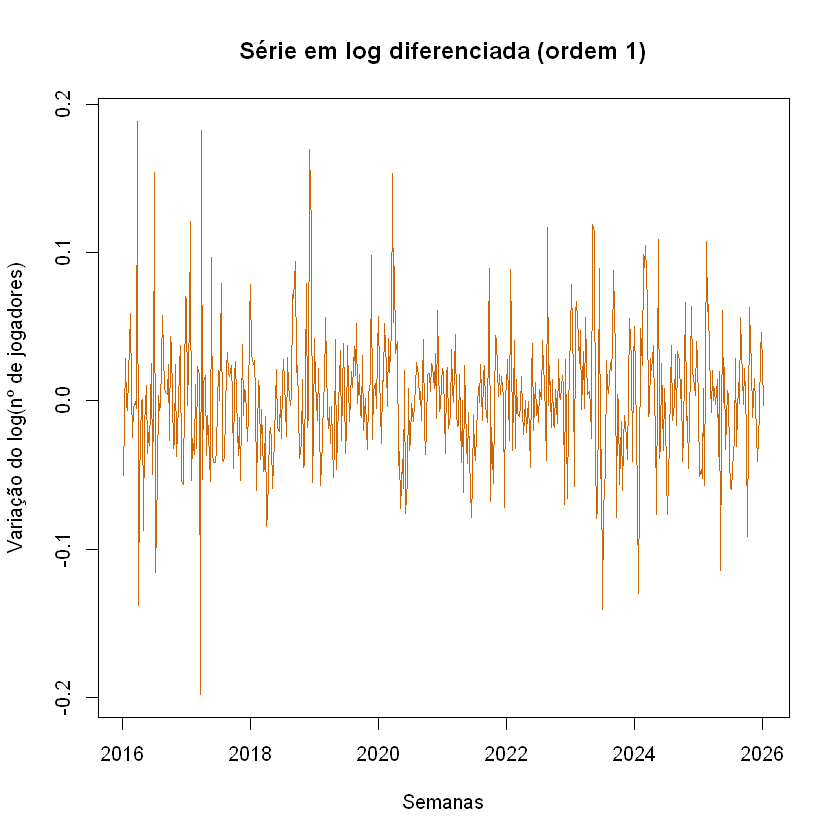

In [196]:
serie <- log(serie)
serie_diff <- diff(serie)
plot(serie_diff,
     main = "Série em log diferenciada (ordem 1)",
     xlab = "Semanas",
     ylab = "Variação do log(nº de jogadores)",
     col  = "darkorange3")


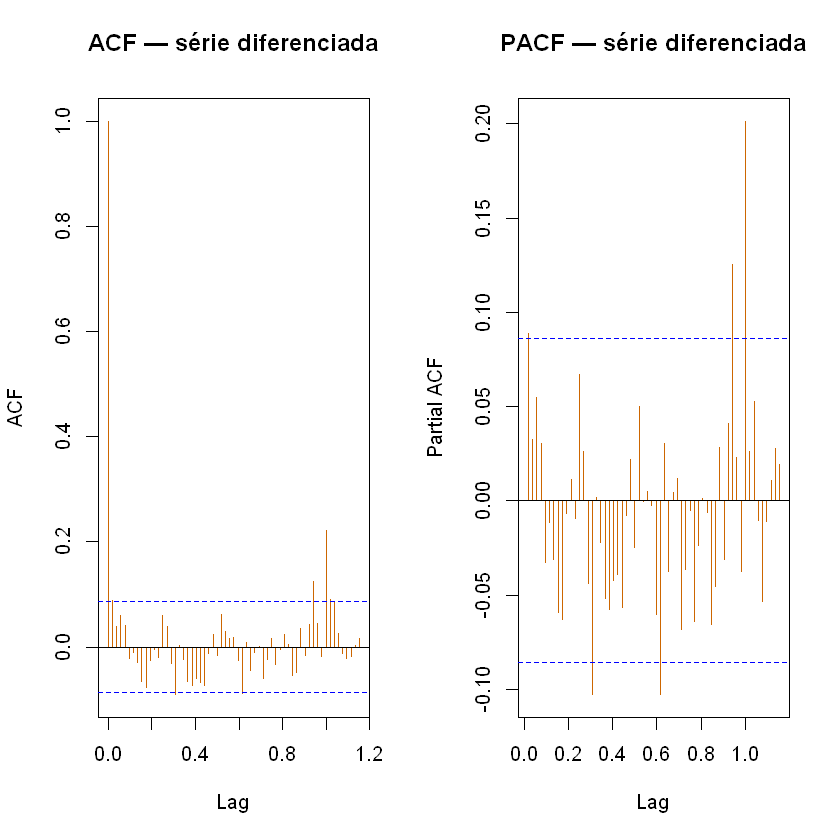

In [209]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))


In [197]:
#modelo <- auto.arima(serie, stepwise = FALSE)
modelo <- Arima(serie, order = c(1,1,2),
  seasonal = list(order = c(0,0,1),period = 52),xreg = dummies)
summary(modelo)


Series: serie 
Regression with ARIMA(1,1,2)(0,0,1)[52] errors 

Coefficients:
          ar1     ma1     ma2    sma1   LS220   TC384    LS391
      -0.9522  0.9893  0.0229  0.2709  0.1594  0.1098  -0.1221
s.e.   0.0580  0.0729  0.0463  0.0460  0.0400  0.0371   0.0398

sigma^2 = 0.001722:  log likelihood = 920.26
AIC=-1824.53   AICc=-1824.25   BIC=-1790.48

Training set error measures:
                      ME       RMSE        MAE         MPE      MAPE      MASE
Training set 0.001278891 0.04117487 0.03009168 0.008875282 0.2204688 0.1518893
                      ACF1
Training set -0.0009548183


	Ljung-Box test

data:  Residuals from Regression with ARIMA(1,1,2)(0,0,1)[52] errors
Q* = 89.648, df = 100, p-value = 0.7616

Model df: 4.   Total lags used: 104



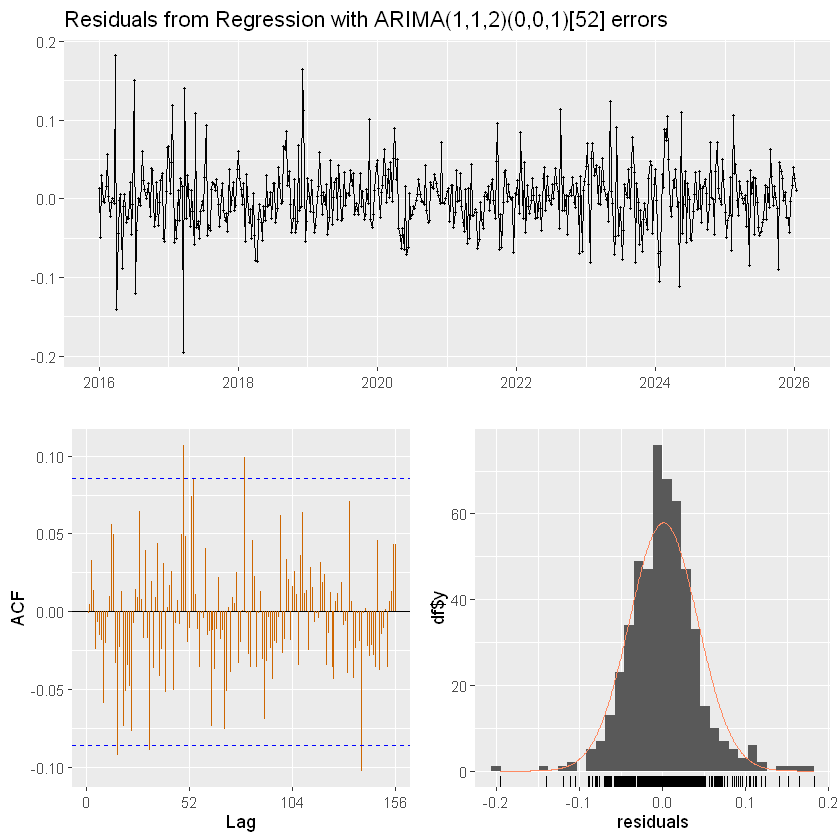

In [198]:
checkresiduals(modelo, col = "darkorange3")


In [199]:
Box.test(residuals(modelo), lag = 20, type = "Ljung-Box", fitdf = sum(modelo$arma[1:4]))



	Box-Ljung test

data:  residuals(modelo)
X-squared = 16.469, df = 16, p-value = 0.4207



	Shapiro-Wilk normality test

data:  res
W = 0.96661, p-value = 1.617e-09


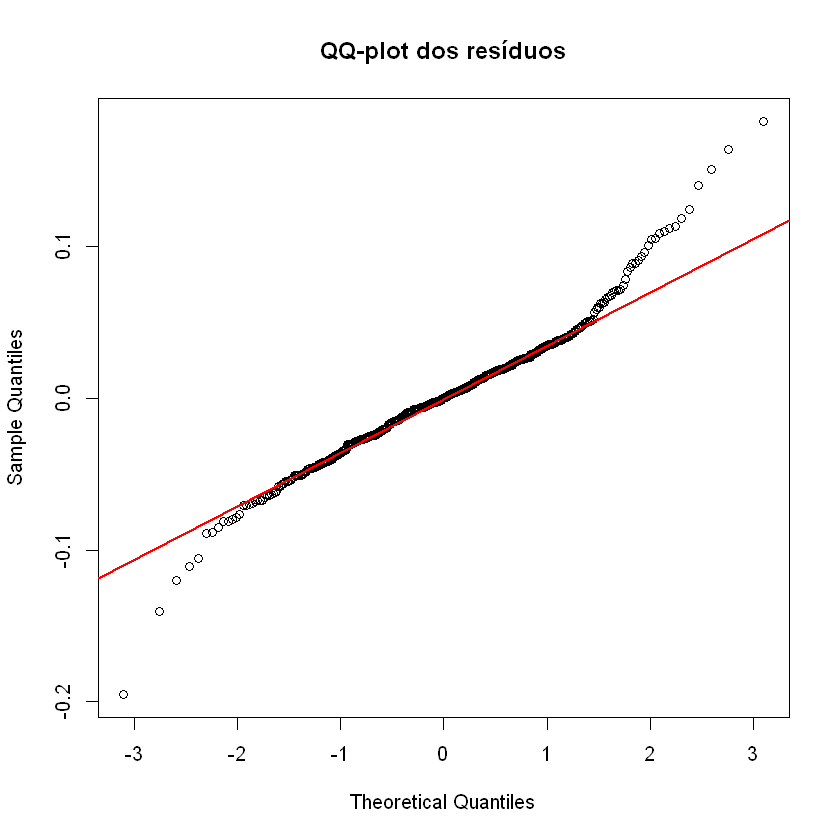

In [200]:
res <- residuals(modelo)

# QQ-plot
qqnorm(res, main = "QQ-plot dos resíduos")
qqline(res, col = "red", lwd = 2)

# Teste de Shapiro-Wilk
shapiro.test(res)


In [201]:
t_index <- seq_along(res)
bptest(res ~ t_index)



	studentized Breusch-Pagan test

data:  res ~ t_index
BP = 3.2078, df = 1, p-value = 0.07329


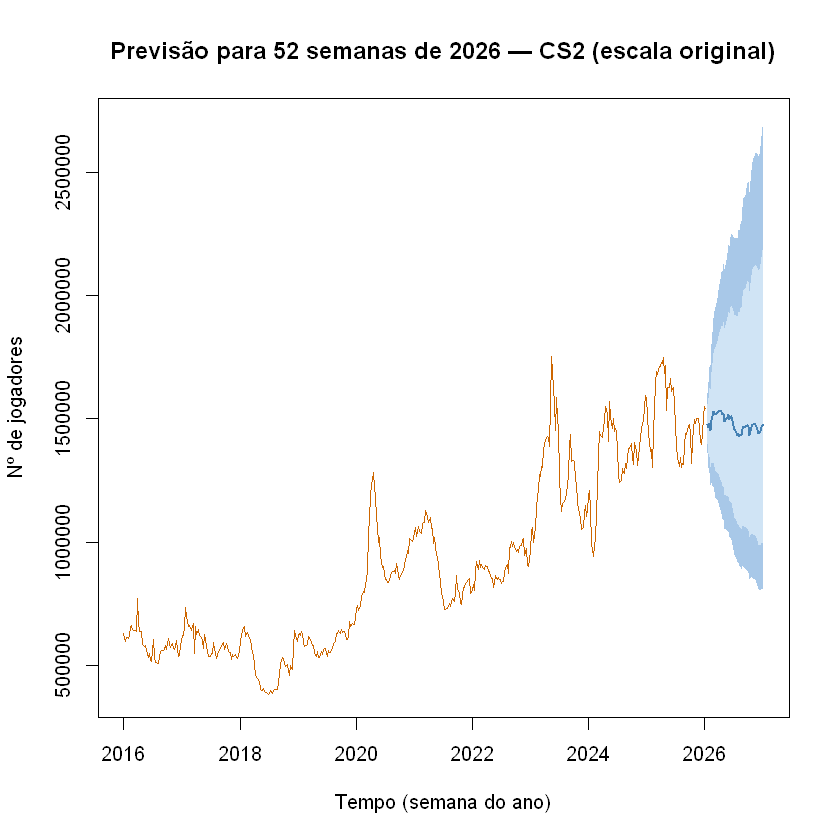

In [202]:
h     <- 52  # horizonte de previsão (semanas)

xreg_futuro <- matrix(0,nrow = h,ncol = ncol(dummies))
colnames(xreg_futuro) <- colnames(dummies)

prev  <- forecast(modelo, h = h, xreg = xreg_futuro)  # previsão na escala log

# Reversão para a escala original (nº de jogadores), via exp(), para facilitar a leitura
prev_original        <- prev
prev_original$mean   <- exp(prev$mean)
prev_original$lower  <- exp(prev$lower)
prev_original$upper  <- exp(prev$upper)
prev_original$x      <- exp(prev$x)

plot(prev_original,
     main    = paste("Previsão para", h, "semanas de 2026 — CS2 (escala original)"),
     xlab    = "Tempo (semana do ano)",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     shadecols = c("#a8c8e8", "#d0e4f5"),
     flwd    = 2)



In [ ]:
cs <- read.csv("steamdb_chart_730.csv", sep = ';')

cs_semanal_todos <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2026-06-24")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = max(Players, na.rm = TRUE)) # os dados de 2026 ainda não estão completos, então peguei o máximo de cada semana como uma aproximação para não perder nenhuma semana

cat("Dimensões:", nrow(cs_semanal_todos), "semanas\n")
tail(cs_semanal_todos)

Dimensões: 547 semanas


semana,jogadores
<date>,<int>
2026-05-18,1488364
2026-05-25,1492812
2026-06-01,1482802
2026-06-08,1532609
2026-06-15,1497573
2026-06-22,1573727


In [204]:
serie_total <- ts(cs_semanal_todos$jogadores,
            start     = c(2016, 1),
            frequency = 52)

# mesma transformação logarítmica aplicada à série completa (treino + teste)
serie_total <- log(serie_total)

cat("Início:", start(serie_total), "| Fim:", end(serie_total),
    "| Observações:", length(serie_total), "\n")


Início: 2016 1 | Fim: 2026 27 | Observações: 547 


In [205]:
n_total <- length(serie_total)
n_teste  <- 25  # as primeiras 25 semanas de 2026
n_treino <- n_total - n_teste

serie_treino <- head(serie_total, n_treino)  # em log
serie_teste  <- tail(serie_total, n_teste)   # em log

#iremos usar o mesmo modelo já que ele foi ajustado para a série completa em log, mas vamos apenas fazer a previsão para as primeiras 25 semanas de 2026



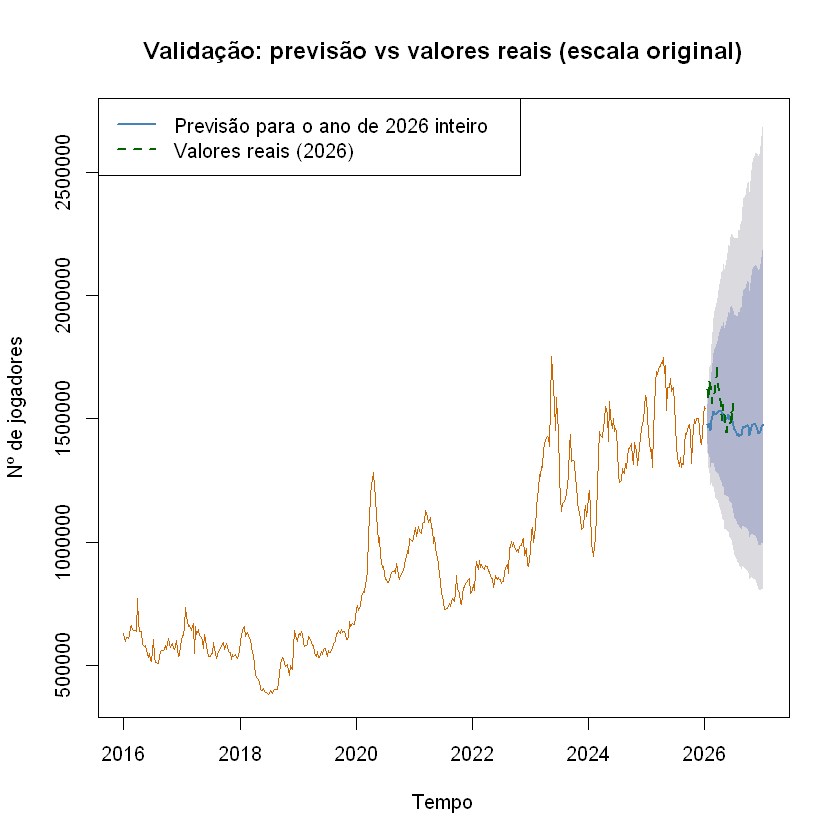

In [206]:
# Previsão para o período de teste (na escala log)
prev_teste <- forecast(modelo, h = n_teste, xreg = xreg_futuro)

# Reversão para a escala original antes de plotar/comparar
prev_teste_original        <- prev_teste
prev_teste_original$mean  <- exp(prev_teste$mean)
prev_teste_original$lower <- exp(prev_teste$lower)
prev_teste_original$upper <- exp(prev_teste$upper)
prev_teste_original$x     <- exp(prev_teste$x)

serie_teste_original <- exp(serie_teste)

# Visualização: série real vs previsão (nº de jogadores)
plot(prev_teste_original,
     main    = "Validação: previsão vs valores reais (escala original)",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)
lines(serie_teste_original, col = "darkgreen", lwd = 2, lty = 2)
legend("topleft",
       legend = c("Previsão para o ano de 2026 inteiro", "Valores reais (2026)"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2), lwd = 2)



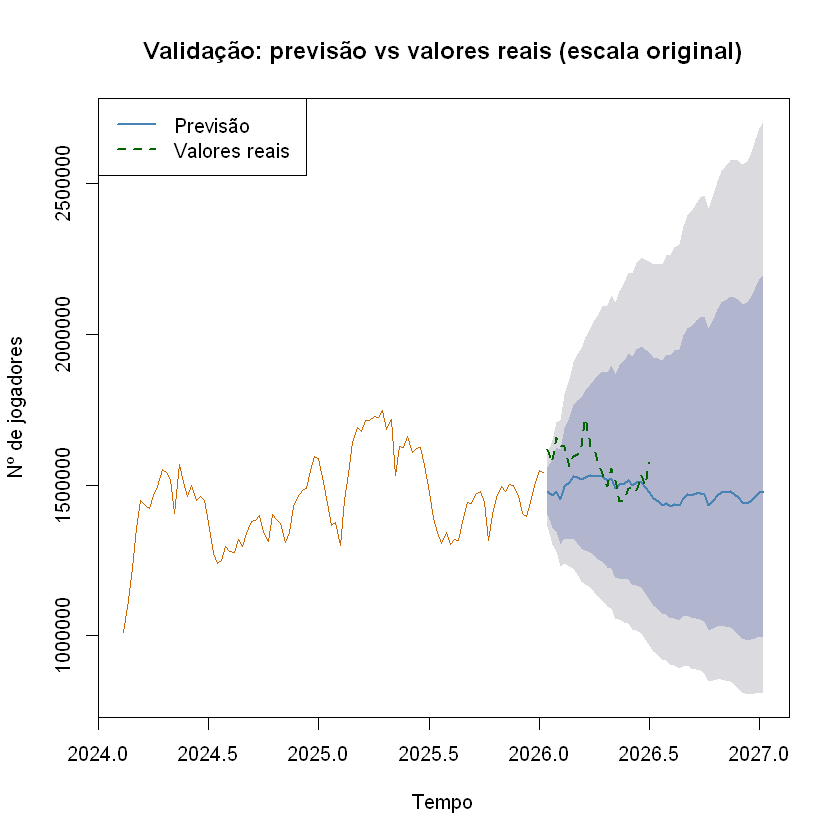

In [207]:
plot(prev_teste_original,
     include = 100,
     main    = "Validação: previsão vs valores reais (escala original)",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)

lines(serie_teste_original, col = "darkgreen", lwd = 2, lty = 2)

legend("topleft",
       legend = c("Previsão", "Valores reais"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2),
       lwd    = 2)


In [210]:
# Erros calculados na escala original (nº de jogadores), após reverter o log com exp()
erros <- as.vector(serie_teste_original) - as.vector(prev_teste_original$mean)

MAE  <- mean(abs(erros))
RMSE <- sqrt(mean(erros^2))
MAPE <- mean(abs(erros / as.vector(serie_teste_original))) * 100

cat(sprintf("MAE  = %10.0f jogadores\n", MAE))
cat(sprintf("RMSE = %10.0f jogadores\n", RMSE))
cat(sprintf("MAPE = %10.2f %%\n", MAPE))



Warning message in as.vector(serie_teste_original) - as.vector(prev_teste_original$mean):
"comprimento do objeto maior não é múltiplo do comprimento do objeto menor"
Warning message in erros/as.vector(serie_teste_original):
"comprimento do objeto maior não é múltiplo do comprimento do objeto menor"


MAE  =      94606 jogadores
RMSE =     113451 jogadores
MAPE =       5.91 %
